In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    # plt.style.use('belle2_serif')
    plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark, lumi
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

Welcome to JupyROOT 6.26/04


In [4]:
def load_root_files(dir_list, tags, tree, cut, variables, bdt_cut):
    # file_map = {tag: [] for tag in tags}
    # for tag in tags:
    #     for d in dir_list:
    #         path = os.path.join(d, f"weighted_{tag}.BCS.root")
    #         if os.path.exists(path):
    #             file_map[tag].append(path)
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            # pattern = os.path.join(d,f"{tree}", "min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
            pattern = os.path.join(d,f"{tree}", "no_bdt", "weighted", f"weighted_{tag}*.root")
            # print(pattern)
            matched_files = glob.glob(pattern)
            matched_files.sort()
            file_map[tag].extend(matched_files)
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")
        
    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        dataframes[tag] = df.query(cut)
    return dataframes

def load_data_files(data_dir_list, tree, cut, variables):
    dfs = []
    for d in data_dir_list:
        # print(os.path.join(d, f"{tree}","min_unc_search", f"{bdt_cut}", "*BDT.root"))
        # for file in glob.glob(os.path.join(d, f"{tree}","min_unc_search", f"{bdt_cut}", "*BDT.root")):
        for file in glob.glob(os.path.join(d, f"{tree}","no_bdt", f"{bdt_cut}", "*BDT.root")):
            print(file)
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)

def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, nbins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, nbins+1)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    # Data points
    data_hist, _ = np.histogram(data_df[var], bins=xbins)
    ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    # ax.legend(loc="upper left", ncol=2, prop={'size':13})
    ax.legend(loc="best", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()



In [21]:
# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi_K"
cut = "Dp_M>0 & rank_Dp_chiProb==1 & (Dp_M<1.83 | Dp_M>2.02) & BDT > 0.77"
variables = ["Dp_M",  "rank_Dp_chiProb", "etapip_pipipi_K_Eta_M_bf", "etapip_pipipi_K_Eta_InvM_bf", "BDT", "etapip_pipipi_K_Pi0_M_bf", "etapip_pipipi_K_Pi0_InvM_bf"]

# bdt_cut="0.77"
bdt_cut=""

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

In [22]:
# mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
# mc_dirs = [
#     f"{mc_base}/15rd_jae_e7_18_4S_v3",
#     f"{mc_base}/15rd_jae_e20_b26_v1",
#     f"{mc_base}/15rd_jae_e20_e26_4S_v2",
#     f"{mc_base}/15rd_jae_e21_5S_scan_v1",
#     f"{mc_base}/15rd_jae_mori_off_v1",
# ]
mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260429_nopi0veto"

mc_dirs = [
    f"{mc_base}/15rd_Etap_e7_18_4S_v3",
    f"{mc_base}/15rd_Etap_e20_b26_v1",
    f"{mc_base}/15rd_Etap_e20_e26_4S_v2",
    f"{mc_base}/15rd_Etap_e21_5S_scan_v1",
    f"{mc_base}/15rd_Etap_mori_off_v1",
]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables + ["ds_weight"], bdt_cut)

ccbar: 18 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found


In [23]:
# 실데이터
# data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7"
# data_dirs = [
#     f"{data_base}/jae_13_had_4S_off_v1",
#     f"{data_base}/jae_13_had_4S_v3",
#     f"{data_base}/jae_23_had_4S_off_v1",
#     f"{data_base}/jae_23_had_4S_v1",
#     f"{data_base}/jae_23_had_5Sscan_10657_v1",
#     f"{data_base}/jae_23_had_5Sscan_10706_v1",
#     f"{data_base}/jae_23_had_5Sscan_10751_v1",
#     f"{data_base}/jae_23_had_5Sscan_10810_v1",
# ]
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7"
data_dirs = [
    f"{data_base}/Eta_13_had_4S_off_v1",
    f"{data_base}/Eta_13_had_4S_v3",
    f"{data_base}/Eta_23_had_4S_off_v1",
    f"{data_base}/Eta_23_had_4S_v1",
    f"{data_base}/Eta_23_had_5Sscan_10657_v1",
    f"{data_base}/Eta_23_had_5Sscan_10706_v1",
    f"{data_base}/Eta_23_had_5Sscan_10751_v1",
    f"{data_base}/Eta_23_had_5Sscan_10810_v1",
]
data_df = load_data_files(data_dirs, tree, cut, variables)


/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_off_v1/etapip_pipipi_K/no_bdt/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_pipipi_K/no_bdt/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_pipipi_K/no_bdt/sub01.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_pipipi_K/no_bdt/sub02.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_pipipi_K/no_bdt/sub03.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapip_pipipi_K/no_bdt/sub04.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_260429_loose_v7/Eta_13_had_4S_v3/etapi

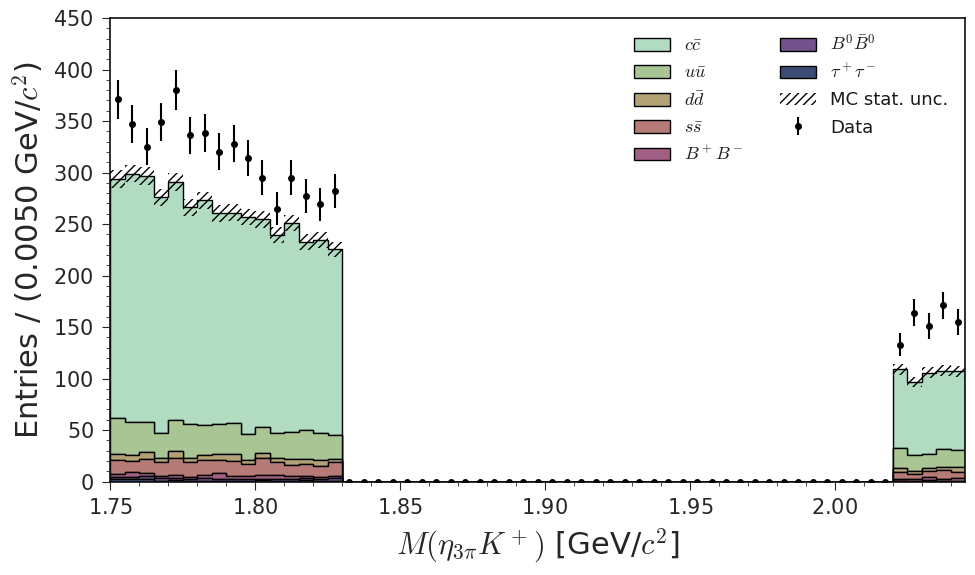

In [24]:
var = "Dp_M"
bins = (1.75,2.045)
nbins = 59
xlabel = r"$M(\eta_{3\pi}K^+)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_stack_with_data_blinded_fitv12_yes_bdt.png")

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins, xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_stack_with_data_blinded_fitv12_yes_bdt_Eta_M_bf.png


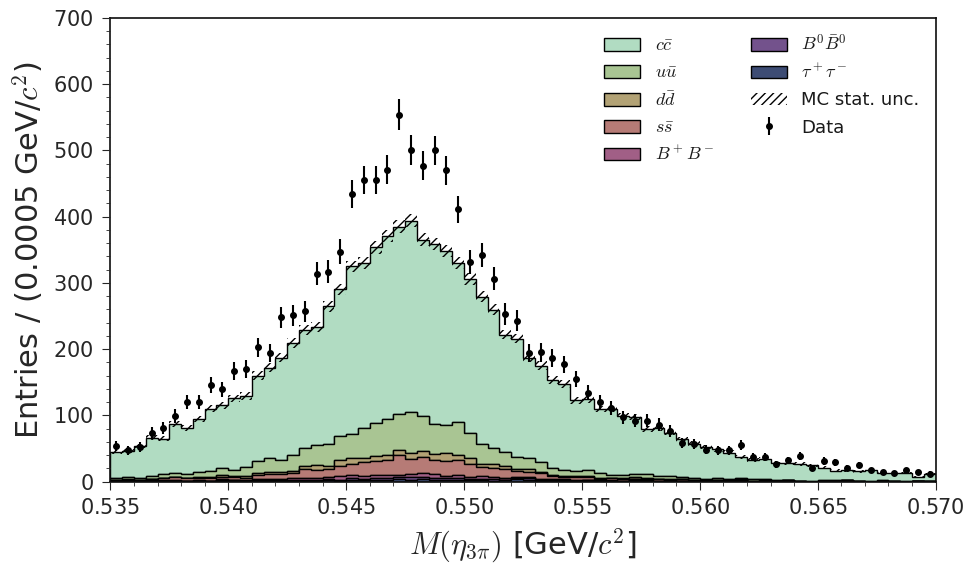

In [25]:
var = "etapip_pipipi_K_Eta_M_bf"
bins = (0.535,0.570)
nbins = 70
xlabel = r"$M(\eta_{3\pi})$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_stack_with_data_blinded_fitv12_yes_bdt_Eta_M_bf.png")
# output = "test.png"
print(output)
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins,  xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_stack_with_data_blinded_fitv12_yes_bdt_Pi0_InvM_bf.png


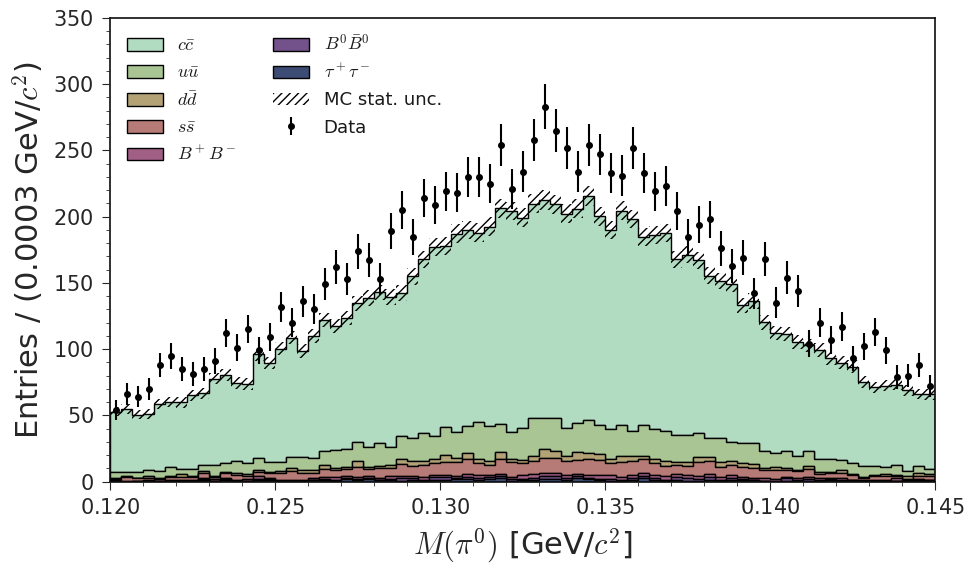

In [26]:
var = "etapip_pipipi_K_Pi0_InvM_bf"
bins = (0.120,0.145)
nbins = 75

xlabel = r"$M(\pi^0)$ [GeV/$c^2$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_stack_with_data_blinded_fitv12_yes_bdt_Pi0_InvM_bf.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, data_df, var, bins, nbins,  xlabel, output)

In [14]:
def load_root_files(dir_list, tags, tree, cut, variables, bdt_cut):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        for d in dir_list:
            pattern = os.path.join(d,f"{tree}", "min_unc_search", f"{bdt_cut}", "weighted", f"weighted_{tag}*.root")
            # print(pattern)
            matched_files = glob.glob(pattern)
            matched_files.sort()
            file_map[tag].extend(matched_files)
    for tag in tags:
        print(f"{tag}: {len(file_map[tag])} files found")
        
    dataframes = {}
    for tag in tags:
        dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ["Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID"]) for fp in file_map[tag]]
        df = pd.concat(dfs, ignore_index=True)
        df["ds_weight"] *= 1/4  # Scale weights
        
        # ccbar 분리
        if tag == "ccbar":
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            df_bkg = df.query("(etapip_Eta_isSignal == 1) & (Pip_genMotherID == etapip_Eta_genMotherID) & ((Pip_genMotherPDG == 431 and Pip_mcPDG == 321) | (Pip_genMotherPDG == -431 and Pip_mcPDG == -321) )").copy()

            df_bkg["ds_weight"] = df_bkg["ds_weight"]
            df_bkg.drop(columns="Dp_isSignal", inplace=True)

            df_bkg2 = df.query("(Dp_isSignal != 1) and ((etapip_Eta_isSignal != 1) or (Pip_genMotherID != etapip_Eta_genMotherID) or ((Pip_genMotherPDG != 431 or Pip_mcPDG != 321) and (Pip_genMotherPDG != -431 or Pip_mcPDG != -321) ) )").copy()
            df_bkg2["ds_weight"] = df_bkg2["ds_weight"]
            df_bkg2.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_sig"] = df_signal.query(cut)
            dataframes["ccbar_bkg"] = df_bkg.query(cut)
            dataframes["ccbar_bkg2"] = df_bkg2.query(cut)
        else:
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)
    return dataframes


def load_data_files(data_dir_list, tree, cut, variables):
    dfs = []
    for d in data_dir_list:
        # print(os.path.join(d, f"{tree}","min_unc_search", f"{bdt_cut}", "*BDT.root"))
        for file in glob.glob(os.path.join(d, f"{tree}","min_unc_search", f"{bdt_cut}", "*BDT.root")):
            print(file)
            try:
                dfs.append(get_pd(file=file, tree=tree, base_filter=cut, variables=variables))
            except Exception as e:
                print(f"[Warn] Cannot load {file}:", e)
    return pd.concat(dfs, ignore_index=True)

def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 60)
    # xbins = np.linspace(*bins, 101)

    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    if data_df is not None:
        # Data points
        data_hist, _ = np.histogram(data_df[var], bins=xbins)
        ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
    
        watermark(t="",logo="Preliminary",px=0.84, py=0.82, fontsize=14)
        lumi(l="$428\; \mathrm{fb}^{-1}$", px=0.78, py=0.90)  
    
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    # ax.set_ylabel(rf"Entries / ({bin_width:.3f} $\mathrm{GeV/c^2}$)")
    ax.set_ylabel(rf"Entries / ({bin_width:.3f} $\mathrm{{GeV/c^2}}$)")
    ax.legend(loc="upper left", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()

In [15]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg2', 'ccbar_bkg', 'ccbar_sig']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'other $c\bar{c}$', r'$D^+_s$ signal',  r'$D^+$ signal'
]


/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_stack_with_data_fitv12_signal_separated.png
ccbar: 18 files found
uubar: 18 files found
ddbar: 11 files found
ssbar: 11 files found
charged: 12 files found
mixed: 12 files found
taupair: 11 files found
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_off_v1/etapip_pipipi_K/min_unc_search/0.77/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_pipipi_K/min_unc_search/0.77/sub00.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_pipipi_K/min_unc_search/0.77/sub01.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3/etapip_pipipi_K/min_unc_search/0.77/sub02.BDT.root
/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7/jae_13_had_4S_v3

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

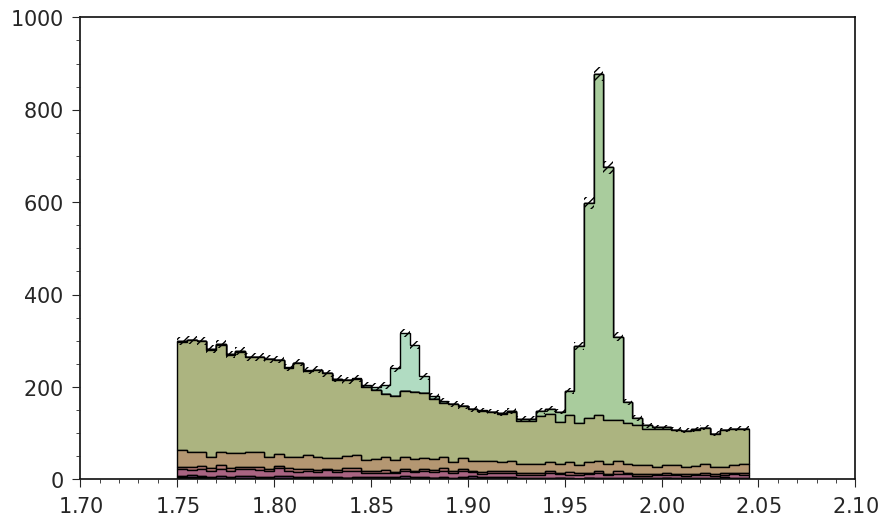

In [13]:

# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi_K"
cut = "Dp_M>0 & rank_Dp_chiProb==1"
variables = ["Dp_M", "ds_weight", "rank_Dp_chiProb"]
var = ["Dp_M","rank_Dp_chiProb"]
bins = (1.71, 2.06)
bins = (1.75,2.045)
bdt_cut="0.77"

xlabel = r"$M(\eta_{3\pi}K^+)$ [$\mathrm{GeV/c^2}$]"
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_stack_with_data_fitv12_signal_separated.png")
# output = "test.png"
print(output)
# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base= "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/EtaHp/MC15rd_loose_v7_260108_nopi0veto"
mc_dirs = [
    f"{mc_base}/15rd_jae_e7_18_4S_v3",
    f"{mc_base}/15rd_jae_e20_b26_v1",
    f"{mc_base}/15rd_jae_e20_e26_4S_v2",
    f"{mc_base}/15rd_jae_e21_5S_scan_v1",
    f"{mc_base}/15rd_jae_mori_off_v1",
]
mc_data = load_root_files(mc_dirs, tags, tree, cut, variables, bdt_cut)

# 실데이터
data_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_EtaHp_loose_v7"
# data_dirs = [f"{data_base}/{d}/{tree}/min_unc_search/0.86" for d in [
#     "jae_13_had_4S_off_v1", "jae_13_had_4S_v3", "jae_23_had_4S_off_v1", "jae_23_had_4S_v1",
#     "jae_23_had_5Sscan_10657_v1", "jae_23_had_5Sscan_10706_v1", "jae_23_had_5Sscan_10751_v1", "jae_23_had_5Sscan_10810_v1"
# ]]
data_dirs = [
    f"{data_base}/jae_13_had_4S_off_v1",
    f"{data_base}/jae_13_had_4S_v3",
    f"{data_base}/jae_23_had_4S_off_v1",
    f"{data_base}/jae_23_had_4S_v1",
    f"{data_base}/jae_23_had_5Sscan_10657_v1",
    f"{data_base}/jae_23_had_5Sscan_10706_v1",
    f"{data_base}/jae_23_had_5Sscan_10751_v1",
    f"{data_base}/jae_23_had_5Sscan_10810_v1",
]
data_df = load_data_files(data_dirs, tree, cut, var)

# 플롯
plot_stack_with_data(mc_data, tag_order, labels, data_df, 'Dp_M', bins, xlabel, output)

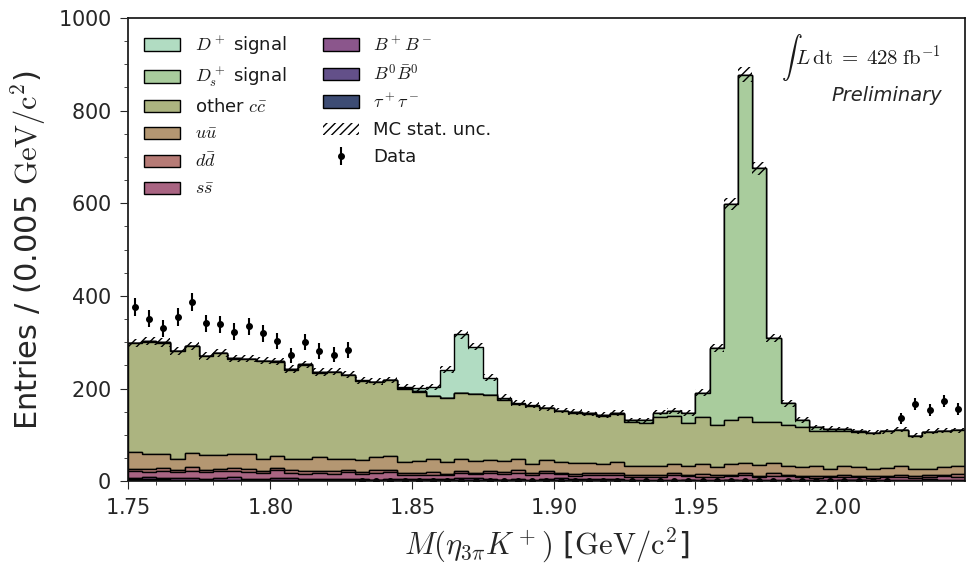

In [16]:
plot_stack_with_data(mc_data, tag_order, labels, data_df, 'Dp_M', bins, xlabel, output)

/media/jykim/T7/saved_plots/DRAW/etaKp/MC15rd_generic/pipipi/MC15rd_etaKp_pipipi_stack_with_data_fitv12_signal_separated_no_data_points.png


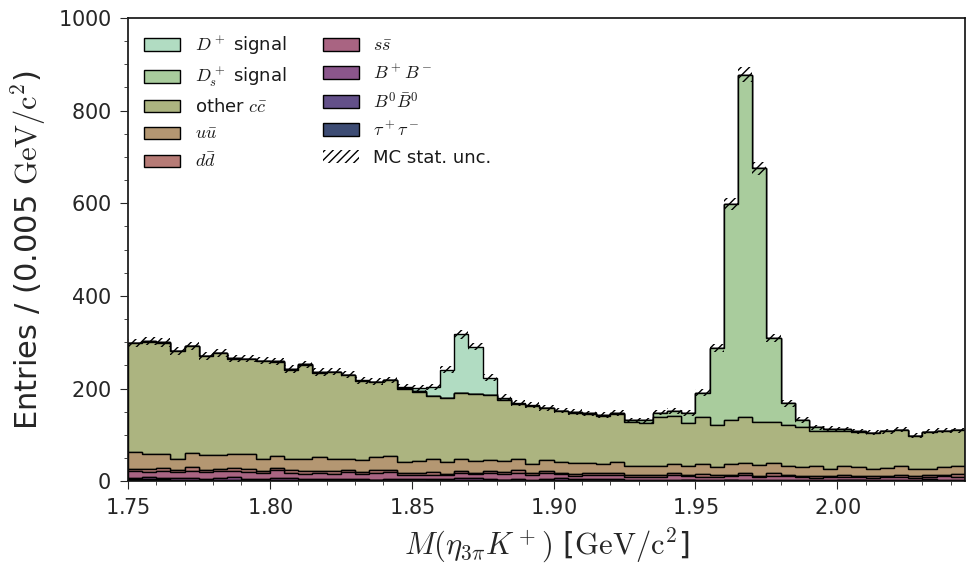

In [17]:
output = os.path.join(plot_dir, "MC15rd_etaKp_pipipi_stack_with_data_fitv12_signal_separated_no_data_points.png")
print(output)
plot_stack_with_data(mc_data, tag_order, labels, None, 'Dp_M', bins, xlabel, output)